In [24]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [25]:
#cargar datos
df_original = pd.read_stata('Mexico-2023-full-data.dta')

# d2 = Ventas, l1 = Empleados, b5 = Año inicio, l10 = Capacitacion 
# k82 = Financiamiento, d3c = % Exportación
cols = {'d2': 'sales', 'l1': 'employees', 'b5': 'start_year', 
        'l10': 'training', 'k82': 'financing', 'd3c': 'export_share'}

df_clean = df_original[list(cols.keys())].copy()
df_clean.rename(columns=cols, inplace=True)

# limpieza 
for col in ['sales', 'employees', 'start_year', 'export_share']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# crear variable binaria de exportador 
df_clean['exporter'] = (df_clean['export_share'] > 0).astype(int)

# borramos cualquier fila que tenga valores faltantes
df_final = df_clean.dropna().copy()

In [27]:
display(df_final.head())

,sales,employees,start_year,training,financing,export_share,exporter
1,29000000,22,1992.0,Yes,"Yes, a line of credit only",0,0
3,135000000,270,2010.0,Yes,"Yes, both a line of credit and a loan",0,0
4,6000000,15,2010.0,Yes,"Yes, a loan only",0,0
5,124000000,95,2007.0,Yes,"Yes, both a line of credit and a loan",0,0
8,46000000,55,1910.0,Yes,"Yes, both a line of credit and a loan",0,0


**Regresión Lineal**

In [28]:
X = df_final[['employees']].values
y = df_final['sales'].values

regr = linear_model.LinearRegression()
regr.fit(X, y)

y_pred = regr.predict(X)

In [30]:
print(f'coeficiente de correlación : {regr.coef_[0]:.2f}')
print(f'Intersección: {regr.intercept_:.2f}')
print(f'Varianza : {r2_score(y, y_pred):.4f}')
print(f'Error Cuadrático de la media: {mean_squared_error(y, y_pred):.2f}')

coeficiente de correlación : 1123120.06
Intersección: 146131.69
Varianza : 0.7335
Error Cuadrático de la media: 6060360753729973.00


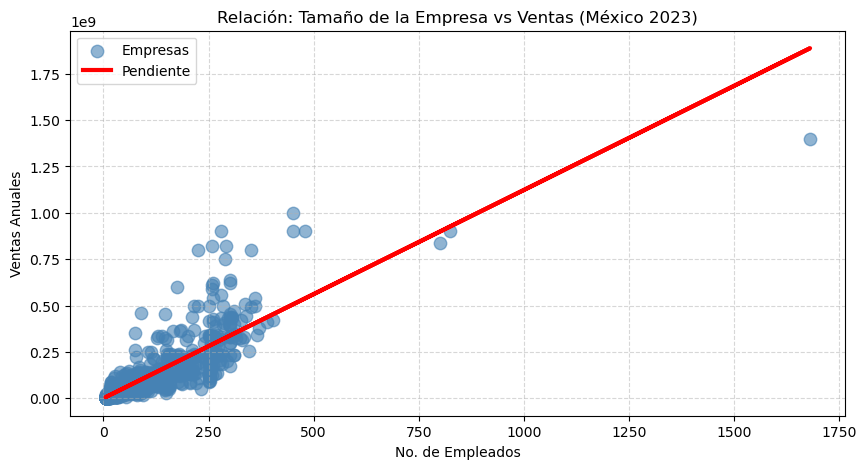

In [39]:
plt.figure(figsize=(10,5))
plt.scatter(X, y, color='steelblue', s=80, label='Empresas', alpha=0.6)
plt.plot(X, y_pred, color='red', linewidth=3, label='Pendiente')
plt.xlabel('No. de Empleados')
plt.ylabel('Ventas Anuales')
plt.title('Relación: Tamaño de la Empresa vs Ventas (México 2023)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Conclusión ##

Con la gráfica podemos ver que entre menos empleados tenga una empresa, las ventas anuales van a disminuir. 
Pero, podemos comprobar que existen muchos factores que afectan las ventas, debido a la dispersión de los puntos 
con respecto a la pendiente.En base a los resultados obtenidos de la Varianza, podemos demostrar que el modelo el altamente efectivo.

**¿qué variables explican mejor las ventas o la productividad de una empresa?**

El número de empleados es una variable que explica significativamente el nivel de ventas de una empresa. El coeficiente positivo indica que, conforme aumenta el número de empleados, también aumentan las ventas.Esto sugiere que el capital humano es un factor clave en el desempeño empresarial, ya que empresas más grandes tienden a generar mayores ingresos.

## CONCLUSIÓN FINAL EN EL ACHIVO "CONCLUSION.md" ##